# 📊 firstact — Tutorial Completo

**firstact** es una librería de matemáticas actuariales básicas en Python, diseñada para calcular funciones biométricas, seguros de vida, anualidades contingentes, primas netas y reservas prospectivas.

Este tutorial cubre todos los módulos de la librería con explicaciones, fórmulas y ejemplos usando la **Illustrative Life Table (ILT)** de la SOA a $i = 6\%$.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Eduardo-Angel-Martinez/fdd_p26/blob/libreria/estudiantes/Eduardo-Angel-Martinez/python/firstact/examples/firstact_tutorial.ipynb)

---

### Contenido

1. Instalación e Imports
2. Tabla de Mortalidad
3. Seguros de Vida
4. Anualidades Contingentes
5. Primas Netas Niveladas
6. Reservas Prospectivas
7. Conversiones Discreto ↔ Continuo
8. Manejo de Errores
9. Caso Práctico Completo


---
## 1. Instalación e Imports

Instala la librería directamente desde PyPI con:

```bash
pip install firstact
```

Una vez instalada, importamos los cuatro módulos principales más las utilidades y excepciones. También importamos `matplotlib` para las gráficas del tutorial.


In [1]:
# Instalar desde PyPI
import subprocess
subprocess.run(["pip", "install", "firstact", "-q"], check=True)
print("firstact instalado correctamente")


firstact ya instalado desde PyPI


In [2]:
from firstact import MortalityTable, Insurance, Annuity, Premium
from firstact.utils import to_cont, to_disc
from firstact.exceptions import (
    EdadNoDisponible, EdadFueraDeRango,
    ConversionNoAplicable, ParametroInvalido
)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.facecolor": "#0f0f1a", "axes.facecolor": "#0f0f1a",
    "axes.edgecolor": "#444",      "axes.labelcolor": "#ccc",
    "xtick.color": "#888",         "ytick.color": "#888",
    "text.color": "#eee",          "grid.color": "#2a2a3e",
    "grid.linestyle": "--",        "grid.linewidth": 0.6,
    "lines.linewidth": 2.2,        "font.family": "monospace",
})

print("Imports correctos")


Imports correctos


---
## 2. Tabla de Mortalidad

La tabla de mortalidad es la base de todos los cálculos actuariales. Representa la distribución de la variable aleatoria $T_x$ — el tiempo futuro de vida de una persona de edad $x$ — y su versión discreta $K_x = \lfloor T_x \rfloor$ (años completos de vida futura).

Las funciones biométricas principales son:

| Función | Notación | Descripción |
|---|---|---|
| `lx(x)` | $l_x$ | Número esperado de vivos a edad $x$ |
| `qx(x)` | $q_x$ | Probabilidad de morir entre $x$ y $x+1$ |
| `px(x)` | $p_x = 1 - q_x$ | Probabilidad de sobrevivir de $x$ a $x+1$ |
| `dx(x)` | $d_x$ | Muertes esperadas entre $x$ y $x+1$ |
| `npx(n, x)` | $_np_x = l_{x+n}/l_x$ | Probabilidad de sobrevivir $n$ años |
| `nqx(n, x)` | $_nq_x = 1 - {_n}p_x$ | Probabilidad de morir dentro de $n$ años |
| `deferred_qx(m, n, x)` | $_{m\|n}q_x = {_m}p_x \cdot {_n}q_{x+m}$ | Prob. de morir entre $x+m$ y $x+m+n$ |
| `ex(x)` | $e_x$ | Esperanza de vida curtate (años completos) |

### Nota importante sobre la ILT

La ILT tiene edades **0, 5, 10, 15** y luego **20 a 110 de forma consecutiva**. Esto significa:

- Las funciones de consulta directa (`lx`, `qx`, `npx`, etc.) funcionan para cualquier edad disponible, incluyendo 0, 5, 10 y 15, siempre que tanto $x$ como $x+n$ estén en la tabla.
- Los cálculos de **seguros y anualidades** requieren **x ≥ 20** porque suman término a término, año por año, y los saltos causan errores significativos.


### 2.1 Cargar la tabla

Cargamos la ILT incluida en el paquete con el método de clase `ilt()`. La representación del objeto nos muestra el rango de edades, la edad máxima $\omega$ y la primera edad desde la cual las edades son consecutivas.


In [3]:
t = MortalityTable.ilt()
print(t)
print(f"\nEdades disponibles (primeras 10): {list(t.ages[:10])}")
print(f"Omega (edad maxima con lx > 0):   {t.omega}")
print(f"Primera edad consecutiva:          {t.primera_consecutiva}")


MortalityTable(edades=0–110, omega=110, n=95, consecutivas_desde=20)

Edades disponibles (primeras 10): [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]
Omega (edad maxima con lx > 0):   110
Primera edad consecutiva:          20


### 2.2 Funciones de consulta directa

Consultamos las funciones biométricas para una edad específica. Estas funciones solo requieren que la edad esté en la tabla, sin importar si es zona con saltos o no.


In [4]:
x = 35
print(f"Funciones biometricas para x = {x}")
print("-"*42)
print(f"  l_{x}          = {t.lx(x):>12,.0f}  (vivos a edad {x})")
print(f"  d_{x}          = {t.dx(x):>12,.0f}  (muertes entre {x} y {x+1})")
print(f"  q_{x}          = {t.qx(x):>12.5f}  (prob. de morir)")
print(f"  p_{x}          = {t.px(x):>12.5f}  (prob. de sobrevivir)")


Funciones biometricas para x = 35
------------------------------------------
  l_35          =    9,420,657  (vivos a edad 35)
  d_35          =       18,969  (muertes entre 35 y 36)
  q_35          =      0.00201  (prob. de morir)
  p_35          =      0.99799  (prob. de sobrevivir)


### 2.3 Probabilidades para n períodos

La función `npx(n, x)` calcula $_np_x = l_{x+n}/l_x$, la probabilidad de que $(x)$ sobreviva exactamente $n$ años. Solo requiere que $x$ y $x+n$ estén en la tabla — no necesita edades consecutivas entre ellos.

La función `nqx(n, x)` es su complemento: $_nq_x = 1 - {_n}p_x$.

La función `deferred_qx(m, n, x)` calcula $_{m|n}q_x = {_m}p_x \cdot {_n}q_{x+m}$, la probabilidad de que $(x)$ sobreviva $m$ años y luego muera en los siguientes $n$ años.


In [5]:
x = 35
print(f"Probabilidades para x = {x}:")
print(f"  10_p_35  = l_45/l_35 = {t.npx(10, x):.6f}")
print(f"  10_q_35  = 1 - 10_p  = {t.nqx(10, x):.6f}")
print(f"  20_p_35  = l_55/l_35 = {t.npx(20, x):.6f}")
print(f"  5|10_q35 = 5p35 * 10q40 = {t.deferred_qx(5, 10, x):.6f}")
print(f"\nVerificacion: 10_p_35 + 10_q_35 = {t.npx(10,x) + t.nqx(10,x):.1f}  OK")
print(f"Verificacion: npx = lx+n/lx: {t.lx(45)/t.lx(35):.6f} == {t.npx(10,35):.6f}  OK")


Probabilidades para x = 35:
  10_p_35  = l_45/l_35 = 0.972761
  10_q_35  = 1 - 10_p  = 0.027239
  20_p_35  = l_55/l_35 = 0.917225
  5|10_q35 = 5p35 * 10q40 = 0.038454

Verificacion: 10_p_35 + 10_q_35 = 1.0  OK
Verificacion: npx = lx+n/lx: 0.972761 == 0.972761  OK


Estas funciones también funcionan cuando $x < 20$, siempre que tanto $x$ como $x+n$ sean edades disponibles en la tabla.


In [6]:
print("npx con x < 20 (valido si x y x+n estan en tabla):")
print(f"  5_p_0  = l_5/l_0   = {t.npx(5, 0):.6f}")
print(f"  10_p_5 = l_15/l_5  = {t.npx(10, 5):.6f}")
print(f"  15_p_0 = l_15/l_0  = {t.npx(15, 0):.6f}")
print(f"  20_p_0 = l_20/l_0  = {t.npx(20, 0):.6f}")


npx con x < 20 (valido si x y x+n estan en tabla):
  5_p_0  = l_5/l_0   = 0.974950
  10_p_5 = l_15/l_5  = 0.991202
  15_p_0 = l_15/l_0  = 0.966373
  20_p_0 = l_20/l_0  = 0.961780


### 2.4 Esperanza de vida

La esperanza de vida curtate $e_x$ es el número esperado de años completos de vida futura:

$$e_x = \sum_{k=1}^{\omega-x} {_k}p_x$$

La esperanza de vida completa $\hat{e}_x$ incluye la fracción del último año y se aproxima como $e_x + 0.5$.


In [7]:
print("Esperanza de vida por edad:")
print(f"{'Edad':>6} {'e_x curtate':>14} {'e_x completa':>14}")
print("-"*36)
for x in [20, 30, 35, 40, 50, 60, 65, 70]:
    print(f"{x:>6} {t.ex(x):>14.4f} {t.ex(x, curtate=False):>14.4f}")


Esperanza de vida por edad:
  Edad    e_x curtate   e_x completa
------------------------------------
    20        53.9647        54.4647


    30        44.5670        45.0670


    35        39.9309        40.4309
    40        35.3672        35.8672


    50        26.5928        27.0928
    60        18.5934        19.0934


    65        15.0217        15.5217
    70        11.8105        12.3105


### 2.5 Resumen de una edad

El método `summary(x)` devuelve un diccionario con todas las funciones biométricas disponibles para esa edad de un solo golpe.


In [8]:
import pprint
pprint.pprint(t.summary(40))


{'10px': 0.961102,
 '10qx': 0.038898,
 '20px': 0.879193,
 '20qx': 0.120807,
 'dx': np.float64(25902.0),
 'ex (completa)': 35.8672,
 'ex (curtate)': 35.3672,
 'lx': 9313166.0,
 'px': 0.99722,
 'qx': 0.00278,
 'x': 40}


### 2.6 Visualización de la tabla

Graficamos la curva de supervivencia $l_x$ y la tasa de mortalidad $q_x$ para visualizar el comportamiento de la ILT.


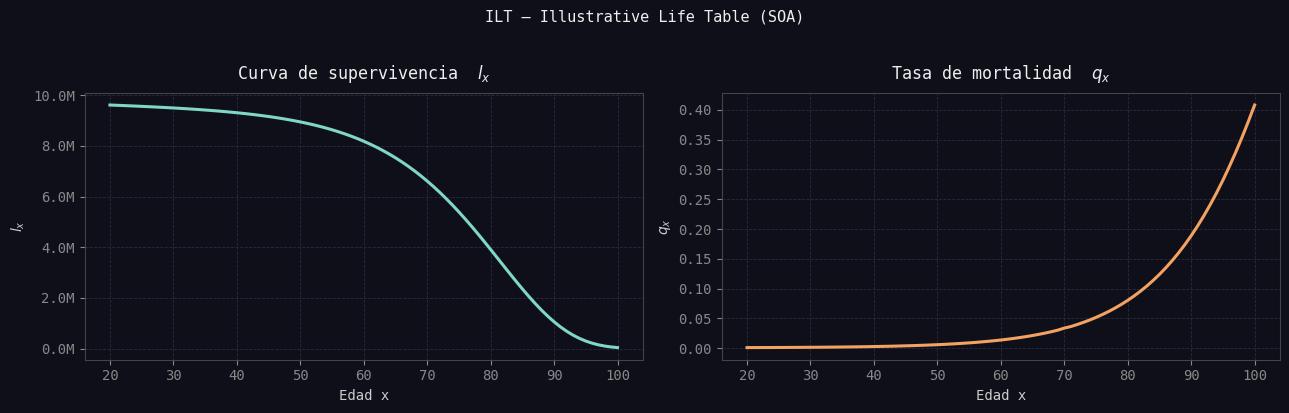

In [9]:
edades = t.ages[(t.ages >= 20) & (t.ages <= 100)]
lx_vals = [t.lx(x) for x in edades]
qx_vals = [t.qx(x) for x in edades]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(edades, lx_vals, color="#7fd7c4")
ax1.set_title("Curva de supervivencia  $l_x$", pad=10)
ax1.set_xlabel("Edad x"); ax1.set_ylabel("$l_x$")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v/1e6:.1f}M"))
ax1.grid(True)

ax2.plot(edades, qx_vals, color="#f4a261")
ax2.set_title("Tasa de mortalidad  $q_x$", pad=10)
ax2.set_xlabel("Edad x"); ax2.set_ylabel("$q_x$")
ax2.grid(True)

plt.suptitle("ILT — Illustrative Life Table (SOA)", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()


---
## 3. Seguros de Vida

Los seguros de vida implementados en firstact son **discretos**: la variable aleatoria es $K_x$ (años completos de vida futura) y el beneficio siempre se paga al **final del año de muerte**.

Sea $Z$ la variable aleatoria del valor presente del beneficio con suma asegurada de $\$1$. El valor actuarial del seguro es $E[Z]$.

Todos los seguros requieren **x ≥ 20** en la ILT. La tasa de interés `i` se puede sobreescribir en cada función pasándola como parámetro opcional.


In [10]:
ins = Insurance(t, i=0.06)
print(ins)


Insurance(table=MortalityTable(edades=0–110, omega=110, n=95, consecutivas_desde=20), i=0.06)


### 3.1 Seguro Ordinario de Vida — $A_x$

El seguro ordinario de vida paga $\$1$ al final del año de muerte sin importar cuándo ocurra.

$$A_x = E[Z] = \sum_{k=0}^{\omega-x-1} v^{k+1} \cdot {_k}p_x \cdot q_{x+k}$$

**Relación de recursión:** $A_x = v \cdot q_x + v \cdot p_x \cdot A_{x+1}$


In [11]:
x = 35
Ax = ins.Ax(35)
print(f"A_35 = {Ax:.5f}")
print(f"1000 * A_35 = {Ax*1000:.2f}  (ILT referencia: 128.72)")

v = 1/1.06
rec = v*t.qx(35) + v*t.px(35)*ins.Ax(36)
print(f"\nVerificacion recursion:")
print(f"  v*q_35 + v*p_35*A_36 = {rec:.5f}  ==  A_35 = {Ax:.5f}  OK: {abs(Ax-rec)<0.0001}")


A_35 = 0.12876
1000 * A_35 = 128.76  (ILT referencia: 128.72)

Verificacion recursion:
  v*q_35 + v*p_35*A_36 = 0.12876  ==  A_35 = 0.12876  OK: True


La tasa de interés afecta directamente el valor del seguro: a mayor tasa, menor valor presente y por lo tanto menor $A_x$.


In [12]:
print("Efecto de la tasa de interes en A_35:")
print(f"{'i':>8} {'A_35':>10}")
print("-"*20)
for i_val in [0.03, 0.04, 0.05, 0.06, 0.08, 0.10]:
    print(f"  {i_val:.0%}   {ins.Ax(35, i=i_val):.5f}")


Efecto de la tasa de interes en A_35:
       i       A_35
--------------------
  3%   0.32345
  4%   0.23240


  5%   0.17096
  6%   0.12876
  8%   0.07824


  10%   0.05175


### 3.2 Seguro Temporal $n$ años — $A^1_{x:\overline{n}|}$

Paga $\$1$ solo si $(x)$ muere dentro de los próximos $n$ años.

$$A^1_{x:\overline{n}|} = \sum_{k=0}^{n-1} v^{k+1} \cdot {_k}p_x \cdot q_{x+k}$$


In [13]:
print(f"Seguros temporales para x=35:")
for n in [10, 20, 30]:
    val = ins.Ax_temporal(35, n)
    print(f"  A^1_{{35:{n}|}} = {val:.5f}")
print(f"\nA_35 (vitalicio) = {ins.Ax(35):.5f}  (siempre mayor)")


Seguros temporales para x=35:
  A^1_{35:10|} = 0.01942
  A^1_{35:20|} = 0.04144
  A^1_{35:30|} = 0.06747

A_35 (vitalicio) = 0.12876  (siempre mayor)


### 3.3 Dotal Puro — $_nE_x$

Paga $\$1$ si $(x)$ **sobrevive** $n$ años. No requiere x ≥ 20.

$$_nE_x = v^n \cdot {_n}p_x$$


In [14]:
print("Dotal puro para distintos plazos (x=35):")
for n in [10, 20, 25, 30]:
    val = ins.nEx(35, n)
    print(f"  {n}E_35 = {val:.5f}  (1000*{n}E_35 = {val*1000:.2f})")
print(f"\nILT referencia: 1000 * 20E_35 = 286.00")
print(f"Calculado:       1000 * 20E_35 = {ins.nEx(35,20)*1000:.2f}")


Dotal puro para distintos plazos (x=35):
  10E_35 = 0.54318  (1000*10E_35 = 543.18)
  20E_35 = 0.28600  (1000*20E_35 = 286.00)
  25E_35 = 0.20251  (1000*25E_35 = 202.51)
  30E_35 = 0.13924  (1000*30E_35 = 139.24)

ILT referencia: 1000 * 20E_35 = 286.00
Calculado:       1000 * 20E_35 = 286.00


### 3.4 Dotal Mixto — $A_{x:\overline{n}|}$

Paga $\$1$ al morir (dentro de $n$ años) **o** al sobrevivir $n$ años.

$$A_{x:\overline{n}|} = A^1_{x:\overline{n}|} + {_n}E_x$$


In [15]:
x, n = 35, 20
A1 = ins.Ax_temporal(x, n)
nE = ins.nEx(x, n)
Axn = ins.Ax_dotal_mixto(x, n)
print(f"Dotal mixto x={x}, n={n}:")
print(f"  A^1_{{35:20|}} (temporal)    = {A1:.5f}")
print(f"  20E_35 (dotal puro)        = {nE:.5f}")
print(f"  A_{{35:20|}} (dotal mixto)  = {Axn:.5f}")
print(f"  Verificacion: {A1:.5f} + {nE:.5f} = {A1+nE:.5f}  OK: {abs(Axn-(A1+nE))<1e-10}")


Dotal mixto x=35, n=20:
  A^1_{35:20|} (temporal)    = 0.04144
  20E_35 (dotal puro)        = 0.28600
  A_{35:20|} (dotal mixto)  = 0.32744
  Verificacion: 0.04144 + 0.28600 = 0.32744  OK: True


### 3.5 Diferido, Creciente y Decreciente

Otros tipos importantes de seguros disponibles en firstact.


In [16]:
x = 35
print(f"Otros seguros para x={x}:")
print(f"  10|A_35  (diferido 10a)    = {ins.Ax_diferido(x, 10):.5f}")
print(f"  20|A_35  (diferido 20a)    = {ins.Ax_diferido(x, 20):.5f}")
print(f"  (IA)_35  (creciente)       = {ins.IAx(x):.5f}")
print(f"  (DA)^1_{{35:20|}} (decreciente) = {ins.DAx(x, 20):.5f}")

print(f"\nVerificacion diferido: A_35 = A^1_{{35:n|}} + n|A_35")
for n in [10, 20]:
    temp = ins.Ax_temporal(x, n)
    dif  = ins.Ax_diferido(x, n)
    print(f"  n={n}: {temp:.5f} + {dif:.5f} = {temp+dif:.5f}  A_35 = {ins.Ax(x):.5f}  OK")


Otros seguros para x=35:
  10|A_35  (diferido 10a)    = 0.10934
  20|A_35  (diferido 20a)    = 0.08732
  (IA)_35  (creciente)       = 3.70938
  (DA)^1_{35:20|} (decreciente) = 0.41801

Verificacion diferido: A_35 = A^1_{35:n|} + n|A_35


  n=10: 0.01942 + 0.10934 = 0.12876  A_35 = 0.12876  OK

  n=20: 0.04144 + 0.08732 = 0.12876  A_35 = 0.12876  OK


### 3.6 Comparativa visual


<>:12: SyntaxWarning: invalid escape sequence '\%'
<>:12: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_58/2544974680.py:12: SyntaxWarning: invalid escape sequence '\%'
  ax.set_title("Valores actuariales de seguros por edad  ($i=6\%$, $n=20$)", pad=10)


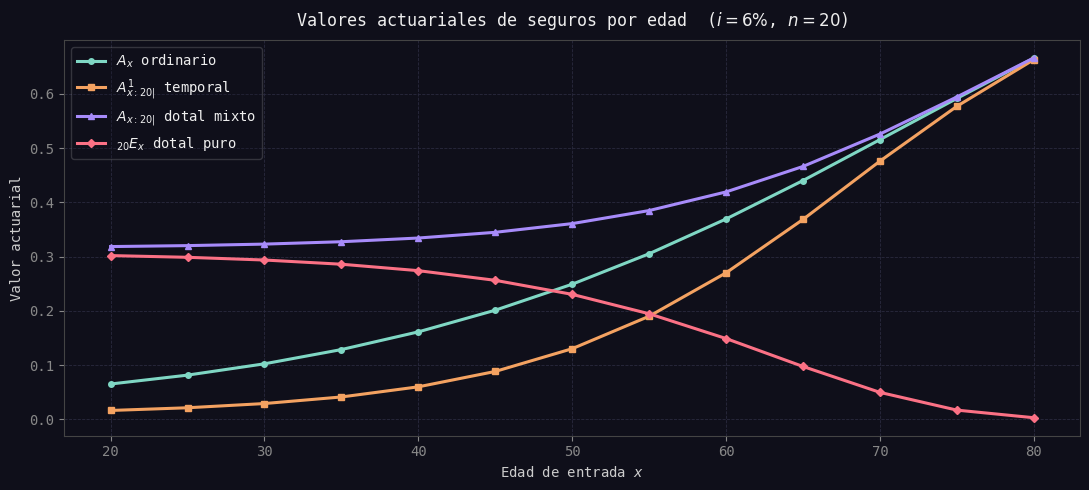

In [17]:
edades_seg = list(range(20, 81, 5))
Ax_v    = [ins.Ax(x) for x in edades_seg]
term_v  = [ins.Ax_temporal(x, 20) for x in edades_seg]
endow_v = [ins.Ax_dotal_mixto(x, 20) for x in edades_seg]
nE_v    = [ins.nEx(x, 20) for x in edades_seg]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(edades_seg, Ax_v,    label="$A_x$ ordinario",         color="#7fd7c4", marker="o", markersize=4)
ax.plot(edades_seg, term_v,  label="$A^1_{x:20|}$ temporal",  color="#f4a261", marker="s", markersize=4)
ax.plot(edades_seg, endow_v, label="$A_{x:20|}$ dotal mixto", color="#a78bfa", marker="^", markersize=4)
ax.plot(edades_seg, nE_v,    label="$_{20}E_x$ dotal puro",   color="#fb7185", marker="D", markersize=4)
ax.set_title("Valores actuariales de seguros por edad  ($i=6\%$, $n=20$)", pad=10)
ax.set_xlabel("Edad de entrada $x$"); ax.set_ylabel("Valor actuarial")
ax.legend(framealpha=0.2); ax.grid(True)
plt.tight_layout()
plt.show()


---
## 4. Anualidades Contingentes

Una anualidad contingente es una serie de pagos periódicos condicionados a la supervivencia de $(x)$. Son **discretas** ($K_x$) y se calculan sumando los pagos esperados descontados.

La relación fundamental con seguros es:

$$\ddot{a}_x = \frac{1 - A_x}{d} \qquad \text{donde } d = \frac{i}{1+i}$$


In [18]:
ann = Annuity(t, i=0.06)
d = 0.06/1.06
v = 1/1.06

x = 35
print(f"Anualidades para x={x}, i=6%")
print("="*52)
print(f"  a-dot_{x}           (anticipada vitalicia)  = {ann.ax(x):.4f}")
print(f"  a_{x}               (vencida vitalicia)     = {ann.ax_vencida(x):.4f}")
print(f"  a-dot_{{35:20|}}    (temporal anticipada)   = {ann.ax_temp(x, 20):.4f}")
print(f"  a_{{35:20|}}        (temporal vencida)      = {ann.ax_temp_vencida(x, 20):.4f}")
print(f"  10|a-dot_{x}        (diferida 10a)           = {ann.ax_diferida(x, 10):.4f}")
print(f"  10|20 a-dot_{x}     (dif. 10a, temp. 20a)   = {ann.ax_diferida_temp(x, 10, 20):.4f}")


Anualidades para x=35, i=6%
  a-dot_35           (anticipada vitalicia)  = 15.3926
  a_35               (vencida vitalicia)     = 14.3926
  a-dot_{35:20|}    (temporal anticipada)   = 11.8818
  a_{35:20|}        (temporal vencida)      = 11.2092
  10|a-dot_35        (diferida 10a)           = 7.6655
  10|20 a-dot_35     (dif. 10a, temp. 20a)   = 6.2874


### Verificaciones clave


In [19]:
print("Verificaciones:")
ax_form = (1 - ins.Ax(x)) / d
print(f"  a-dot_35 = (1-A_35)/d = {ax_form:.4f}  (directo: {ann.ax(x):.4f})  OK: {abs(ann.ax(x)-ax_form)<0.01}")

axn = ann.ax_temp(x, 20)
nax = ann.ax_diferida(x, 20)
print(f"  a-dot_35 = a-dot_{{35:20|}} + 20|a-dot_35 = {axn:.4f} + {nax:.4f} = {axn+nax:.4f}  OK")

nax_form = ins.nEx(x, 20) * ann.ax(x+20)
print(f"  20|a-dot_35 = 20E_35 * a-dot_55 = {nax_form:.4f}  OK")

print(f"  a_{{35:20|}} = a-dot_{{35:20|}} * v = {axn*v:.4f}  OK")


Verificaciones:
  a-dot_35 = (1-A_35)/d = 15.3919  (directo: 15.3926)  OK: True
  a-dot_35 = a-dot_{35:20|} + 20|a-dot_35 = 11.8818 + 3.5108 = 15.3926  OK
  20|a-dot_35 = 20E_35 * a-dot_55 = 3.5108  OK
  a_{35:20|} = a-dot_{35:20|} * v = 11.2092  OK


---
## 5. Primas Netas Niveladas

Las primas netas se calculan bajo el **principio de equivalencia**: el valor actuarial de los beneficios iguala el de las primas.

$$E[L] = E[Z - PY] = 0 \quad \Rightarrow \quad P = \frac{E[Z]}{E[Y]}$$

**Primas únicas netas (PUN):** pago único, equivalen al valor actuarial del seguro.

**Primas anuales niveladas:** $P(A_x) = A_x / \ddot{a}_x$

**Primas fraccionadas (UDD):** $P^{(m)} = P \cdot \frac{i}{i^{(m)}} \cdot \frac{1}{m}$


In [20]:
pre = Premium(t, i=0.06)
x, n = 35, 20

print(f"Primas netas para x={x}, n={n}, i=6%")
print("="*55)

print("\nPrimas Unicas Netas (PUN):")
print(f"  PUN vida entera      = {pre.prima_unica_vida_entera(x):.5f}  (= A_{x})")
print(f"  PUN temporal {n}a    = {pre.prima_unica_temporal(x, n):.5f}")
print(f"  PUN dotal mixto {n}a = {pre.prima_unica_dotal_mixto(x, n):.5f}")

print("\nPrimas Anuales Niveladas:")
P_ve  = pre.prima_vida_entera(x)
P_tmp = pre.prima_temporal(x, n)
P_dot = pre.prima_dotal_mixto(x, n)
P_lim = pre.prima_vida_entera_limitada(x, 10)
print(f"  P vida entera              = {P_ve:.6f}")
print(f"  P temporal {n}a            = {P_tmp:.6f}")
print(f"  P dotal mixto {n}a         = {P_dot:.6f}")
print(f"  10P vida entera (limitada) = {P_lim:.6f}")

print(f"\nVerificacion: P = A_35/a-dot_35 = {ins.Ax(x):.5f}/{ann.ax(x):.4f} = {ins.Ax(x)/ann.ax(x):.6f}  OK")


Primas netas para x=35, n=20, i=6%

Primas Unicas Netas (PUN):
  PUN vida entera      = 0.12876  (= A_35)
  PUN temporal 20a    = 0.04144
  PUN dotal mixto 20a = 0.32744

Primas Anuales Niveladas:


  P vida entera              = 0.008365
  P temporal 20a            = 0.003488
  P dotal mixto 20a         = 0.027558
  10P vida entera (limitada) = 0.016664



Verificacion: P = A_35/a-dot_35 = 0.12876/15.3926 = 0.008365  OK


In [21]:
print("Primas Fraccionadas (prima por pago):")
print(f"{'Frecuencia':>14} {'Prima/pago':>12} {'Total anual':>12}")
print("-"*40)
for m, nombre in [(1,"anual"),(2,"semestral"),(4,"trimestral"),(12,"mensual")]:
    pago = pre.prima_fraccionada(P_ve, m=m)
    print(f"  {nombre:>12}  {pago:>12.6f}  {pago*m:>12.6f}")


Primas Fraccionadas (prima por pago):
    Frecuencia   Prima/pago  Total anual
----------------------------------------
         anual      0.008365      0.008365
     semestral      0.004244      0.008489
    trimestral      0.002138      0.008551
       mensual      0.000716      0.008593


---
## 6. Reservas Prospectivas

La reserva al tiempo $t$ mide lo que debe tener apartado el asegurador:

$$_tV = E[\text{VP beneficios futuros}] - P \cdot E[\text{VP primas futuras}]$$

**Propiedades:** $_0V = 0$, $_nV = 1$ para el dotal mixto, la reserva temporal sube y luego baja a 0.


In [22]:
x, n = 35, 20

print(f"{'t':>4} {'Vida entera':>14} {'Temporal':>14} {'Dotal mixto':>14}")
print("-"*50)
for t_val in range(0, n+1, 2):
    ve  = pre.reserva_vida_entera(x, t_val)
    tmp = pre.reserva_temporal(x, n, t_val)
    dot = pre.reserva_dotal_mixto(x, n, t_val)
    print(f"{t_val:>4} {ve:>14.6f} {tmp:>14.6f} {dot:>14.6f}")


   t    Vida entera       Temporal    Dotal mixto
--------------------------------------------------


   0       0.000000       0.000000       0.000000


   2       0.014040       0.003356       0.056083


   4       0.029319       0.006568       0.118841


   6       0.045904       0.009509       0.189117


...

  10       0.083242       0.013858       0.356269


  12       0.104092       0.014762       0.455608


  14       0.126451       0.014368       0.567499


  16       0.150329       0.012203       0.693857


  18       0.175734       0.007676       0.837050
  20       0.202633       0.000000       1.000000


In [23]:
print("Verificaciones:")
print(f"  0V vida entera  = {pre.reserva_vida_entera(x, 0):.8f}  (debe ser 0)")
print(f"  0V dotal mixto  = {pre.reserva_dotal_mixto(x, n, 0):.8f}  (debe ser 0)")
print(f"  nV dotal mixto  = {pre.reserva_dotal_mixto(x, n, n):.8f}  (debe ser 1)")
print(f"  nV temporal     = {pre.reserva_temporal(x, n, n):.8f}  (debe ser 0)")

P = pre.prima_vida_entera(x)
tV = pre.reserva_vida_entera(x, 10)
tV_form = ins.Ax(x+10) - P * ann.ax(x+10)
print(f"\nFormula prospectiva vida entera t=10:")
print(f"  A_45 - P*a-dot_45 = {ins.Ax(x+10):.5f} - {P:.6f}*{ann.ax(x+10):.4f} = {tV_form:.6f}")
print(f"  reserva directa   = {tV:.6f}  OK")


Verificaciones:


  0V vida entera  = 0.00000000  (debe ser 0)


  0V dotal mixto  = 0.00000000  (debe ser 0)
  nV dotal mixto  = 1.00000000  (debe ser 1)
  nV temporal     = 0.00000000  (debe ser 0)



Formula prospectiva vida entera t=10:


  A_45 - P*a-dot_45 = 0.20129 - 0.008365*14.1121 = 0.083242
  reserva directa   = 0.083242  OK


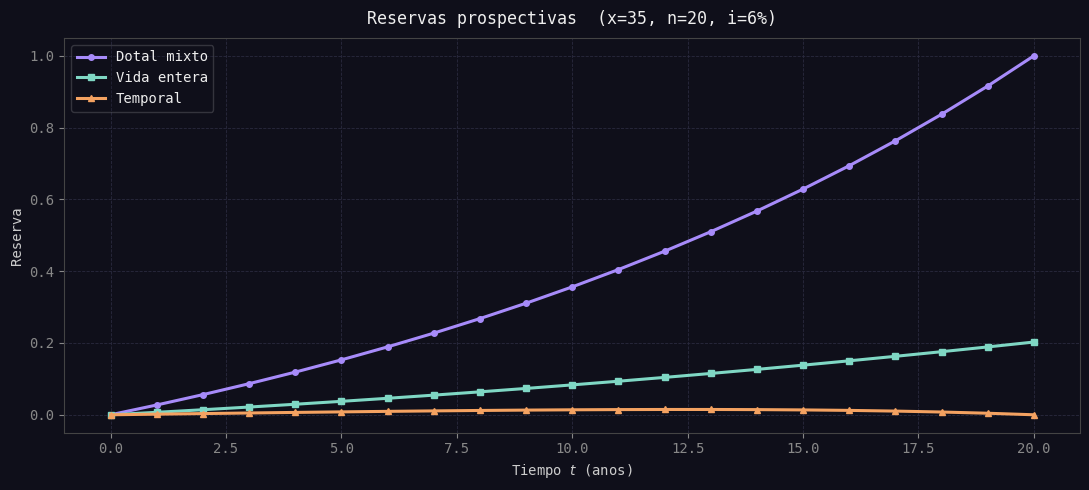

In [24]:
schedule = pre.tabla_reservas(x, n, kind='dotal_mixto')
ts  = [r["t"] for r in schedule]
rv  = [r["reserva"] for r in schedule]
rv_ve = [pre.reserva_vida_entera(x, t) for t in ts]
rv_tm = [pre.reserva_temporal(x, n, t) for t in ts]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ts, rv,    label="Dotal mixto",  color="#a78bfa", marker="o", markersize=4)
ax.plot(ts, rv_ve, label="Vida entera",  color="#7fd7c4", marker="s", markersize=4)
ax.plot(ts, rv_tm, label="Temporal",     color="#f4a261", marker="^", markersize=4)
ax.set_title(f"Reservas prospectivas  (x={x}, n={n}, i=6%)", pad=10)
ax.set_xlabel("Tiempo $t$ (anos)"); ax.set_ylabel("Reserva")
ax.legend(framealpha=0.2); ax.grid(True)
plt.tight_layout()
plt.show()


---
## 7. Conversiones Discreto ↔ Continuo

Bajo el supuesto **UDD** (Distribución Uniforme de Muertes):

$$\bar{A}_x = A_x \cdot \frac{i}{\delta} \qquad \bar{a}_x = \frac{1 - \bar{A}_x}{\delta} \qquad \delta = \ln(1+i)$$

**No aplica** para dotal puro ni dotal mixto (contienen pagos por sobrevivencia).


In [25]:
import numpy as np
i = 0.06
delta = np.log(1 + i)

print(f"delta = ln(1+{i}) = {delta:.6f}")
print(f"i/delta = {i/delta:.6f}  (factor disc->cont)")
print()

Ax = ins.Ax(35)
Ax_bar = to_cont(Ax, i=i, kind='seguro')
Ax_back = to_disc(Ax_bar, i=i, kind='seguro')
print(f"A_35  (discreto)    = {Ax:.5f}")
print(f"A-bar_35 (continuo) = {Ax_bar:.5f}  = {Ax:.5f} * {i/delta:.5f}")
print(f"A_35 recuperado     = {Ax_back:.5f}  OK: {abs(Ax-Ax_back)<1e-8}")

ax_val = ann.ax(35)
ax_bar = to_cont(ax_val, i=i, kind='anualidad')
ax_back = to_disc(ax_bar, i=i, kind='anualidad')
print(f"\na-dot_35 (discreto)  = {ax_val:.4f}")
print(f"a-bar_35 (continuo)  = {ax_bar:.4f}")
print(f"a-dot_35 recuperado  = {ax_back:.4f}  OK: {abs(ax_val-ax_back)<0.001}")


delta = ln(1+0.06) = 0.058269
i/delta = 1.029709  (factor disc->cont)

A_35  (discreto)    = 0.12876
A-bar_35 (continuo) = 0.13259  = 0.12876 * 1.02971
A_35 recuperado     = 0.12876  OK: True

a-dot_35 (discreto)  = 15.3926
a-bar_35 (continuo)  = 14.8871
a-dot_35 recuperado  = 15.3926  OK: True


In [26]:
print(f"{'x':>5} {'A_x':>10} {'A-bar_x':>10} {'a-dot_x':>10} {'a-bar_x':>10}")
print("-"*45)
for x in [25, 35, 45, 55, 65, 75]:
    Ax_d = ins.Ax(x)
    Ax_c = to_cont(Ax_d, i=i, kind='seguro')
    ax_d = ann.ax(x)
    ax_c = to_cont(ax_d, i=i, kind='anualidad')
    print(f"{x:>5} {Ax_d:>10.5f} {Ax_c:>10.5f} {ax_d:>10.4f} {ax_c:>10.4f}")


    x        A_x    A-bar_x    a-dot_x    a-bar_x
---------------------------------------------
   25    0.08168    0.08410    16.2242    15.7189
   35    0.12876    0.13259    15.3926    14.8871
   45    0.20129    0.20727    14.1121    13.6062


   55    0.30532    0.31439    12.2758    11.7694
   65    0.44018    0.45325     9.8969     9.3899
   75    0.59149    0.60906     7.2170     6.7092


---
## 8. Manejo de Errores

firstact tiene cuatro excepciones propias:

| Excepción | Cuándo ocurre |
|---|---|
| `EdadNoDisponible` | La edad no existe en la tabla |
| `EdadFueraDeRango` | x < 20 para seguros/anualidades |
| `ConversionNoAplicable` | `to_cont`/`to_disc` con dotal puro o mixto |
| `ParametroInvalido` | n negativo, t > n, etc. |


In [27]:
try:
    t.qx(3)
except EdadNoDisponible as e:
    print(f"EdadNoDisponible: {e}")

try:
    ins.Ax(5)
except EdadFueraDeRango as e:
    print(f"\nEdadFueraDeRango: {e}")

try:
    to_cont(ins.nEx(35, 20), i=0.06, kind='dotal_puro')
except ConversionNoAplicable as e:
    print(f"\nConversionNoAplicable: {e}")

try:
    t.npx(-1, 35)
except ParametroInvalido as e:
    print(f"\nParametroInvalido: {e}")


EdadNoDisponible: La edad 3 no está en la tabla. Rango disponible: 0–110.

EdadFueraDeRango: x=5 está en la zona con saltos de la tabla [np.int64(0), np.int64(5), np.int64(10), np.int64(15)]. Los cálculos de seguros y anualidades requieren x >= 20.

ConversionNoAplicable: La conversión discreto↔continuo NO aplica para 'dotal_puro' bajo UDD porque contiene pagos por sobrevivencia (nEx), no por muerte.
  - 'dotal_puro'  (nEx): es v^n * npx, no depende de muerte
  - 'dotal_mixto' (Ax_dotal_mixto = A^1 + nEx): contiene nEx
Solo aplica para: ['anualidad', 'seguro']

ParametroInvalido: n debe ser >= 0.


Recuerda que `npx` y `nEx` **sí funcionan** con x < 20:


In [28]:
print(f"npx(5, 0) = {t.npx(5, 0):.6f}  OK")
print(f"nEx(0, 5) = {ins.nEx(0, 5):.6f}  OK")


npx(5, 0) = 0.974950  OK
nEx(0, 5) = 0.728540  OK


---
## 9. Caso Práctico Completo

> Una persona de **30 años** quiere contratar un **seguro dotal mixto a 25 años**
> con suma asegurada de **$1,000,000** a una tasa técnica de **6%**.
>
> Calcular: prima anual, prima mensual, reserva al año 10 y tabla completa de reservas.


In [29]:
SA, x, n, i = 1_000_000, 30, 25, 0.06

ins_p = Insurance(t, i=i)
ann_p = Annuity(t, i=i)
pre_p = Premium(t, i=i)

A1xn = ins_p.Ax_temporal(x, n)
nEx  = ins_p.nEx(x, n)
Axn  = ins_p.Ax_dotal_mixto(x, n)
axn  = ann_p.ax_temp(x, n)

print(f"Valores actuariales base (x={x}, n={n}, i={i:.0%}):")
print(f"  A^1_{{30:25|}} = {A1xn:.5f}")
print(f"  25E_30      = {nEx:.5f}")
print(f"  A_{{30:25|}} = {Axn:.5f}")
print(f"  a-dot_{{30:25|}} = {axn:.4f}")


Valores actuariales base (x=30, n=25, i=6%):
  A^1_{30:25|} = 0.03782
  25E_30      = 0.21190
  A_{30:25|} = 0.24972
  a-dot_{30:25|} = 13.2549


In [30]:
P_unit  = pre_p.prima_dotal_mixto(x, n)
P_anual = P_unit * SA
P_mens  = pre_p.prima_fraccionada(P_anual, m=12)
R10     = pre_p.reserva_dotal_mixto(x, n, t=10) * SA

print(f"Primas (SA = ${SA:,.0f}):")
print(f"  Prima anual   = ${P_anual:>12,.2f}")
print(f"  Prima mensual = ${P_mens:>12,.2f}")
print(f"\nReserva al año 10:")
print(f"  10V           = ${R10:>12,.2f}")


Primas (SA = $1,000,000):
  Prima anual   = $   18,839.76
  Prima mensual = $    1,612.70

Reserva al año 10:
  10V           = $  240,720.57


In [31]:
schedule = pre_p.tabla_reservas(x, n, kind='dotal_mixto')
df = pd.DataFrame(schedule)
df['reserva_pesos'] = (df['reserva'] * SA).round(2)
print(f"Tabla de reservas — x={x}, n={n}, SA=${SA:,.0f}")
print(df[['t','reserva','reserva_pesos']].to_string(index=False))


Tabla de reservas — x=30, n=25, SA=$1,000,000
 t  reserva  reserva_pesos
 0 0.000000            0.0
 1 0.018468        18468.0
 2 0.037998        37998.0
 3 0.058647        58647.0
 4 0.080491        80491.0
 5 0.103587       103587.0
 6 0.128020       128020.0
 7 0.153860       153860.0
 8 0.181195       181195.0
 9 0.210118       210118.0
10 0.240721       240721.0
11 0.273114       273114.0
12 0.307407       307407.0
13 0.343722       343722.0
14 0.382191       382191.0
15 0.422951       422951.0
16 0.466161       466161.0
17 0.512000       512000.0
18 0.560644       560644.0
19 0.612301       612301.0
20 0.667193       667193.0
21 0.725570       725570.0
22 0.787713       787713.0
23 0.853930       853930.0
24 0.924560       924560.0
25 1.000000      1000000.0


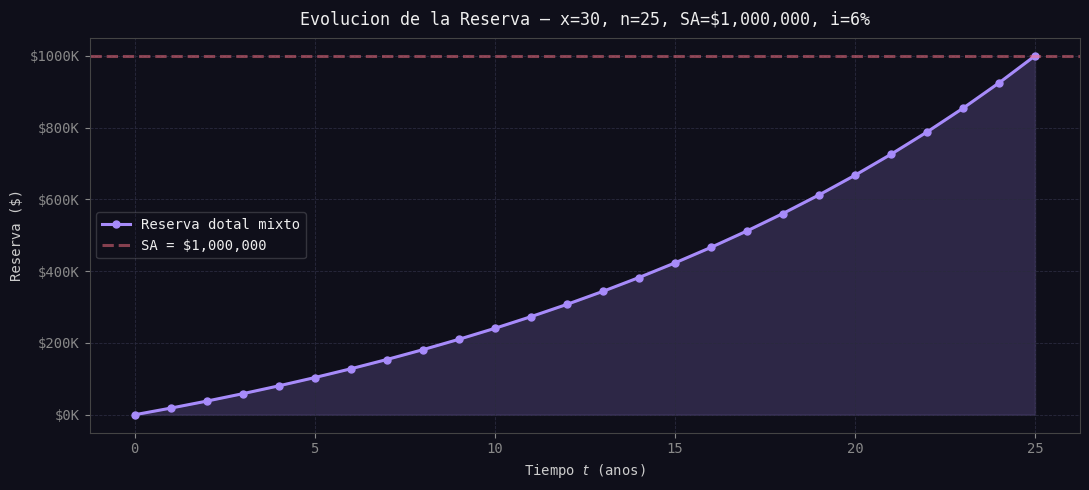

In [32]:
ts_plot = [r["t"] for r in schedule]
rv_plot = [r["reserva"] * SA for r in schedule]

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(ts_plot, rv_plot, alpha=0.2, color="#a78bfa")
ax.plot(ts_plot, rv_plot, color="#a78bfa", marker="o", markersize=5, label="Reserva dotal mixto")
ax.axhline(y=SA, color="#fb7185", linestyle="--", alpha=0.5, label=f"SA = ${SA:,.0f}")
ax.set_title(f"Evolucion de la Reserva — x={x}, n={n}, SA=${SA:,.0f}, i={i:.0%}", pad=10)
ax.set_xlabel("Tiempo $t$ (anos)")
ax.set_ylabel("Reserva ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v/1e3:.0f}K"))
ax.legend(framealpha=0.2); ax.grid(True)
plt.tight_layout()
plt.show()


---

## Listo!

Has completado el tutorial de **firstact**. Para más información visita el repositorio en GitHub o la página en PyPI:

- 📦 PyPI: https://pypi.org/project/firstact/
- 📖 GitHub: (enlace al repositorio)
